Copyright (C) 2025  Diarmuid

This program is free software: you can redistribute it and/or modify\
it under the terms of the GNU General Public License as published by\
the Free Software Foundation, either version 3 of the License, or\
(at your option) any later version.

This program is distributed in the hope that it will be useful,\
but WITHOUT ANY WARRANTY; without even the implied warranty of\
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the\
GNU General Public License for more details.

You should have received a copy of the GNU General Public License\
along with this program.  If not, see <https://www.gnu.org/licenses/>.

----------------------------------------------------------------------

In [46]:
%matplotlib inline
import pandas as pd
import matplotlib. pyplot as plt
import matplotlib.patches as mp
plt.style.use("seaborn-v0_8-whitegrid")
import numpy as np

import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [47]:
dataset = pd.read_csv("Sleep_Health_and_Lifestyle_Dataset.csv")

In [48]:
# Fill any nan values with "None"
dataset["Sleep Disorder"] = dataset["Sleep Disorder"].fillna("None")

age = dataset["Age"].values
sleepDuration = dataset["Sleep Duration"].values
sleepQuality = dataset["Quality of Sleep"].values
physicalActivity = dataset["Physical Activity Level"].values
stressLevel = dataset["Stress Level"].values
heartRate = dataset["Heart Rate"].values
dailySteps = dataset["Daily Steps"].values
coords = np.column_stack((age, sleepDuration, sleepQuality, physicalActivity, stressLevel, heartRate, dailySteps))
y = (dataset["Sleep Disorder"] == "Insomnia").astype(int)

# Data is split into training and testing samples, 30% of the data is used for testing and 70% is used for training
X_train, X_test, y_train, y_test = train_test_split(coords, y, test_size=0.25, random_state=16)

# Train model
lregModel = LogisticRegression(random_state=16, max_iter=1000)
lregModel.fit(X_train, y_train)

# Make prediction
y_pred = lregModel.predict(X_test)

Confusion Matrix:


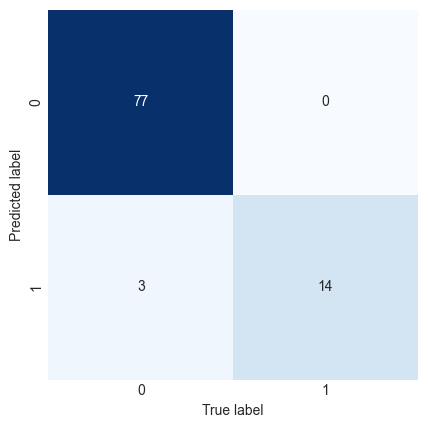

In [41]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")

# Heat map
sns.heatmap(cm.T, square=True, annot=True, fmt='d', cbar=False, cmap='Blues')
plt.xlabel('True label')
plt.ylabel('Predicted label');  

<function matplotlib.pyplot.show(close=None, block=None)>

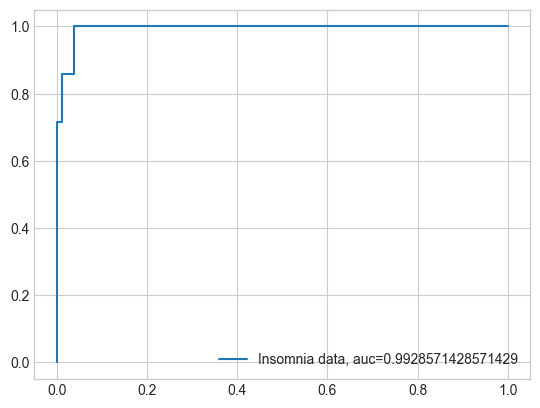

In [49]:
y_pred_proba = lregModel.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr, tpr,  label="Insomnia data, auc=" + str(auc))
plt.legend(loc=4)
plt.show

In [50]:
y = (dataset["Sleep Disorder"] == "Sleep Apnea").astype(int)

# Data is split into training and testing samples, 30% of the data is used for testing and 70% is used for training
X_train, X_test, y_train, y_test = train_test_split(coords, y, test_size=0.25, random_state=16)

# Train model
lregModel = LogisticRegression(random_state=16, max_iter=1000)
lregModel.fit(X_train, y_train)

# Make prediction
y_pred = lregModel.predict(X_test)

Confusion Matrix:


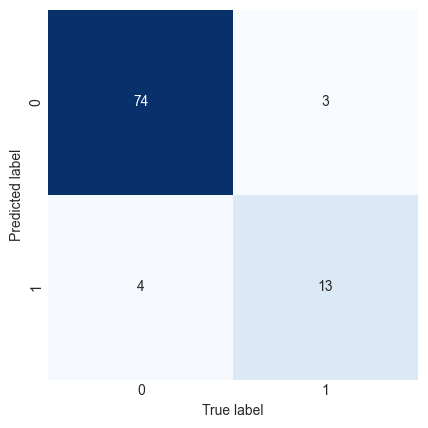

In [51]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")

# Heat map
sns.heatmap(cm.T, square=True, annot=True, fmt='d', cbar=False, cmap='Blues')
plt.xlabel('True label')
plt.ylabel('Predicted label');  

<function matplotlib.pyplot.show(close=None, block=None)>

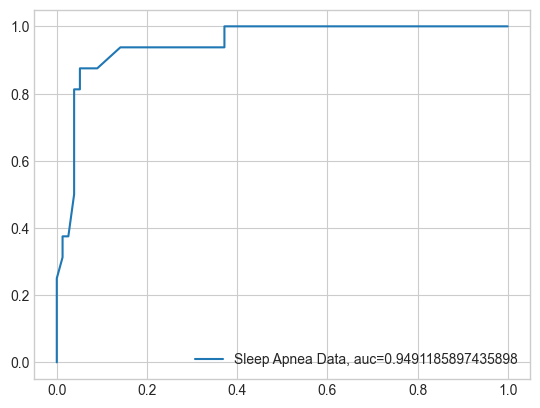

In [52]:
y_pred_proba = lregModel.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr, tpr,  label="Sleep Apnea Data, auc=" + str(auc))
plt.legend(loc=4)
plt.show